# Tarea 2
## Estimación de la Constante de Stefan-Boltzmann
### Efraín Rojas García - C36883


#### Inciso a. Integración de  $I(\omega)$ 

W = $\int_{0}^{\infty} I(\omega) d\omega$ $ = \frac{\hbar}{4\pi^2c^2} \int_0^\infty \frac{\omega^3}{e^{\hbar\omega/(k_BT)}-1}d\omega$ 

La susticion seria los valores de la exponencial: $ x=\frac{\hbar\omega}{k_BT} $ y pues se despeja omega y tambiente se ocupa sacar el $du$.

$d\omega=\frac{k_BT}{\hbar}dx$ y sale de la integral elevado al cubo.

y queda $ W = \frac{k^4_B T^4}{4 \pi^2 c^2 \hbar^3}   \int_{0}^{\infty} \frac{x^3}{e^x - 1}dx$ 

Esta integral se puede aproximar, pero las herramientas necesarias no son requisito del curso, talvez solo transformar el denominador como la serie geometrica, entonces le queda en el numerador queda para usar la función gamma y se llega a la función zeta de Riemann y ahi se aproxima.



#### Inciso b. 
Codigo para evaluar la integral que aparece en la expresión.
Primeramente recordemos hacer el cambio de variable tomando en cuenta que Cuadratura Gaussiana se necesita en el intervalo [-1, 1] por ortogonalidad.


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre

def func(x):
    return x**3 * np.exp(-x) / (1 - np.exp(-x))
#Cambie la forma de la función pq aunque me diera el resultado, a la hora de los errores me daba un error de overflow

def cuadratura_gaussiana(n):
    
    x, w = roots_legendre(n)
    
    t = (x + 1) / 2
    w = w / 2
    
    jacobiano = 1 / (1 - t)**2
    
    integral = np.sum(w * func(t/(1-t)) * jacobiano)
    
    return integral


n = 10

resultado = cuadratura_gaussiana(n)

print("Valor:", resultado)
?

Valor: 6.572142992176111


n =  2 | Integral = 14.327015279267 | Error = 7.8331e+00
n =  4 | Integral = 4.055850790991 | Error = 2.4381e+00
n =  8 | Integral = 6.164619632375 | Error = 3.2932e-01
n = 16 | Integral = 6.499876822954 | Error = 5.9374e-03
n = 32 | Integral = 6.493936442275 | Error = 2.9600e-06
n = 64 | Integral = 6.493939402268 | Error = 1.4495e-12


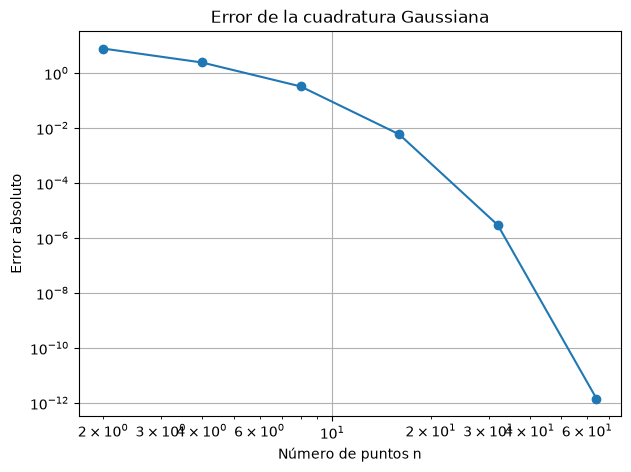

In [50]:

valor_exacto = 6.4939394022668291490960221792470074166485057115123614460978572926
#Sacado de WolframAlpha
error_absoluto = abs(resultado - valor_exacto)

error_relativo = error_absoluto / abs(valor_exacto)

N_values = [2, 4, 8, 16, 32, 64]

resultados = []
errores = []

for n in N_values:
    
    resultado = cuadratura_gaussiana(n)
    error = abs(resultado - valor_exacto)
    resultados.append(resultado)
    errores.append(error)
    
    print(f"n = {n:2d} | Integral = {resultado:.12f} | Error = {error:.4e}")


# Gráfico 
plt.figure(figsize=(7,5))

plt.loglog(N_values, errores, 'o-')

plt.xlabel("Número de puntos n")
plt.ylabel("Error absoluto")
plt.title("Error de la cuadratura Gaussiana")
plt.grid(True)

plt.show()

#### Inciso c.
Si $W=T^2 \sigma$ es lo mismo que el otro valor solo que sin $T^4$, entonces:
$  W = \frac{k^4_B}{4 \pi^2 c^2 \hbar^3}   \int_{0}^{\infty} \frac{x^3}{e^x - 1}dx $

In [39]:
# constantes 
hbar = 1.054571817e-34      
c = 2.99792458e8            
kB = 1.380649e-23           

sigma_exacto = 5.670374419e-8   

n = 64

integral = cuadratura_gaussiana(n)

sigma = (kB**4 / (4 * np.pi**2 * c**2 * hbar**3)) * integral

# Errores
error_absoluto = abs(sigma - sigma_exacto)
error_relativo = error_absoluto / abs(sigma_exacto)
error_porcentual = error_relativo * 100

print("Sigma calculado      =", sigma)
print("Sigma conocido       =", sigma_exacto)
print("Error absoluto       =", error_absoluto)

Sigma calculado      = 5.6703744296087375e-08
Sigma conocido       = 5.670374419e-08
Error absoluto       = 1.0608737601524879e-16
